# Tratando os dados de internações

Este notebook consolida as **internações por doenças respiratórias** (SUS) no **município do Rio de Janeiro** e prepara a **série diária de internações** para modelagem.
O foco é: leitura dos dados brutos anuais, filtros clínicos e geográficos coerentes com exposição ambiental e uma **análise exploratória inicial**.

> **Escopo**: 2012–2025, diagnósticos respiratórios (CID-10 selecionados), residentes da cidade do Rio e permanência hospitalar > 0.

## Objetivos desta etapa
1. **Carregar** todos os parquet anuais (2012–2025) diretamente do GitHub (*raw*).
2. **Padronizar** campos-chave (datas, CID-10) e **filtrar** registros de interesse.
3. **Construir** a série **diária** de internações (`data_dia` × `internacoes`).

## Configurações e importações
Bibliotecas usadas e parâmetros gerais.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
from scipy.stats import linregress
import matplotlib.dates as mdates

In [2]:
INTERNACOES_ANOS_INTERESSE = range(2012, 2019)

## Carregamento e Unificação dos dados do SUS

In [3]:
anos = range(2012, 2026)
tpl = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/RawData/DataSus/dados_filtrados_{ano}.parquet"

dfs = []
for ano in anos:
    url = tpl.format(ano=ano)
    print(f"Lendo: {url}")
    df = pd.read_parquet(url)
    dfs.append(df)

df_sus = pd.concat(dfs, ignore_index=True)

Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/RawData/DataSus/dados_filtrados_2012.parquet
Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/RawData/DataSus/dados_filtrados_2013.parquet
Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/RawData/DataSus/dados_filtrados_2014.parquet
Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/RawData/DataSus/dados_filtrados_2015.parquet
Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/RawData/DataSus/dados_filtrados_2016.parquet
Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/RawData/DataSus/dados_filtrados_2017.parquet
Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/h

## Inspeção inicial

Visão geral de dimensões, tipos, amostra e dados ausentes. A coluna de data principal
virá de `DT_INTER` (quando numérica tipo `YYYYMMDD`) ou de `data_formatada` (se já estiver disponível).

In [ ]:
print("Dimensões:", df_sus.shape)

print("\nTipos:")
print(df_sus.dtypes)

print("\nAmostra:")
display(df_sus.head(5))

print("\nValores ausentes por coluna (top 20):")
na_counts = df_sus.isna().sum().sort_values(ascending=False)
na_perc   = (df_sus.isna().mean()*100).round(2).sort_values(ascending=False)
display(pd.DataFrame({"NA_count": na_counts, "NA_%": na_perc}).head(20))

Dimensões: (5811422, 16)

Tipos:
CGC_HOSP          string[python]
MUNIC_RES         string[python]
NASC              string[python]
SEXO                       Int64
DT_INTER          string[python]
DT_SAIDA          string[python]
DIAG_PRINC        string[python]
DIAG_SECUN        string[python]
IDADE             string[python]
COD_IDADE         string[python]
RACA_COR          string[python]
ETNIA             string[python]
DIAS_PERM         string[python]
MORTE             string[python]
CID_MORTE         string[python]
data_formatada            object
dtype: object

Amostra:


,CGC_HOSP,MUNIC_RES,NASC,SEXO,DT_INTER,DT_SAIDA,DIAG_PRINC,DIAG_SECUN,IDADE,COD_IDADE,RACA_COR,ETNIA,DIAS_PERM,MORTE,CID_MORTE,data_formatada
0,29138328001637,330170,20111123,3,20120101,20120109,J158,,1,3,99,0000,8,0,,2012-01-01
1,33932567000155,330455,19460329,1,20120101,20120131,J449,E148,65,4,02,0000,30,0,,2012-01-01
2,42498717000317,330455,19400425,1,20120101,20120218,J180,,71,4,03,0000,48,1,A419,2012-01-01
3,29138328001637,330170,20110830,1,20120101,20120104,J158,,4,3,99,0000,3,0,,2012-01-01
4,28964252000150,330100,19410619,1,20120101,20120111,J189,,70,4,99,0000,10,0,,2012-01-01



Valores ausentes por coluna (top 20):


,NA_count,NA_%
CGC_HOSP,0,0.0
MUNIC_RES,0,0.0
NASC,0,0.0
SEXO,0,0.0
DT_INTER,0,0.0
DT_SAIDA,0,0.0
DIAG_PRINC,0,0.0
DIAG_SECUN,0,0.0
IDADE,0,0.0
COD_IDADE,0,0.0


## Filtrando dados de saúde

### Filtrando por anos de interesse

Nesta etapa, vamos manter apenas os registros de internação com data entre **2012 e 2018** (inclusive).

Você pode perguntar:  
> “Por que carregar dados de anos posteriores a 2018, se o período de interesse é 2012–2018?”

A resposta é:
- Os dados de internação podem ser inseridos retrospectivamente (registro post-mortem).
- Por isso, eventos de anos anteriores podem aparecer em cargas feitas após 2018.
- Carregar os arquivos até 2025 garante captura completa dos registros de 2012–2018.

In [5]:
df_sus['data_formatada'] = pd.to_datetime(df_sus['data_formatada'], errors='coerce')

df_sus = df_sus[df_sus['data_formatada'].dt.year.isin(INTERNACOES_ANOS_INTERESSE)].copy()
df_sus.sort_values('data_formatada', inplace=True)

display(df_sus.head())
display(df_sus.tail())

,CGC_HOSP,MUNIC_RES,NASC,SEXO,DT_INTER,DT_SAIDA,DIAG_PRINC,DIAG_SECUN,IDADE,COD_IDADE,RACA_COR,ETNIA,DIAS_PERM,MORTE,CID_MORTE,data_formatada
0,29138328001637,330170,20111123,3,20120101,20120109,J158,,1,3,99,0000,8,0,,2012-01-01
858849,,330210,19540705,3,20120101,20120103,J189,,57,4,01,0000,2,0,,2012-01-01
858850,28636579002227,330190,20110103,1,20120101,20120105,J158,,11,3,99,0000,4,0,,2012-01-01
858851,33245556000105,330455,19611001,1,20120101,20120110,J189,,50,4,01,0000,9,0,,2012-01-01
858852,,330610,19260501,1,20120101,20120112,J128,,85,4,01,0000,11,1,J128,2012-01-01


,CGC_HOSP,MUNIC_RES,NASC,SEXO,DT_INTER,DT_SAIDA,DIAG_PRINC,DIAG_SECUN,IDADE,COD_IDADE,RACA_COR,ETNIA,DIAS_PERM,MORTE,CID_MORTE,data_formatada
1953677,,330240,20001216,1,20181231,20190124,J930,0000,18,4,03,0000,24,0,0000,2018-12-31
1953678,,330450,19500320,1,20181231,20190111,J441,0000,68,4,99,0000,11,0,0000,2018-12-31
1953679,29138278003208,330350,19771020,3,20181231,20190105,J930,0000,41,4,99,0000,5,0,0000,2018-12-31
1953711,28683712000171,330040,19710225,1,20181231,20190117,J188,0000,47,4,03,0000,17,0,0000,2018-12-31
5386980,29138328001637,330510,20181105,1,20181231,20190105,J158,0000,1,3,99,0000,5,0,0000,2018-12-31


### Filtrando por CID-10 de Interesse

Nesta etapa, serão filtrados os códigos CID-10 relevantes para nossa análise:

**Códigos selecionados:**
- **Pneumonia:** J18, J15
- **Insuficiência Respiratória:** J21, J96  
- **Bronquites:** J40, J41, J42
- **Enfisema/DPOC:** J43, J44
- **Asma:** J45, J46

In [6]:
cids_associados_a_poluicao = {"J15","J18","J21","J96","J40","J41","J42","J43","J44","J45","J46"}

# Limpando a coluna DIAG_PRINC: convertendo para string, maiúsculas, removendo espaços e caracteres não alfanuméricos
df_sus["DIAG_PRINC"] = (df_sus["DIAG_PRINC"].astype(str).str.upper().str.strip().str.replace(r"[^A-Z0-9]", "",regex=True))

# Extraindo os primeiros 3 caracteres como prefixo CID
df_sus["CID_PREFIXO"] = df_sus["DIAG_PRINC"].str[:3]

# Filtrando o dataframe para incluir apenas linhas com prefixos CID relevantes
sus_filtrado = df_sus[df_sus["CID_PREFIXO"].isin(cids_associados_a_poluicao)].copy()

print(f"Filtered data shape: {sus_filtrado.shape}")
print("\nCID prefix counts:")
print(sus_filtrado["CID_PREFIXO"].value_counts())
print("\nFirst 5 rows of filtered data:")
display(sus_filtrado.head())

Filtered data shape: (3199412, 17)

CID prefix counts:
CID_PREFIXO
J18    1301045
J15     805878
J45     228459
J21     228374
J96     202951
J44     199364
J40     107039
J46      51370
J43      41102
J41      26696
J42       7134
Name: count, dtype: int64

First 5 rows of filtered data:


,CGC_HOSP,MUNIC_RES,NASC,SEXO,DT_INTER,DT_SAIDA,DIAG_PRINC,DIAG_SECUN,IDADE,COD_IDADE,RACA_COR,ETNIA,DIAS_PERM,MORTE,CID_MORTE,data_formatada,CID_PREFIXO
0,29138328001637,330170,20111123,3,20120101,20120109,J158,,1,3,99,0000,8,0,,2012-01-01,J15
858849,,330210,19540705,3,20120101,20120103,J189,,57,4,01,0000,2,0,,2012-01-01,J18
858850,28636579002227,330190,20110103,1,20120101,20120105,J158,,11,3,99,0000,4,0,,2012-01-01,J15
858851,33245556000105,330455,19611001,1,20120101,20120110,J189,,50,4,01,0000,9,0,,2012-01-01,J18
858854,29468055009673,330455,19550319,1,20120101,20120114,J189,,56,4,03,0000,13,0,,2012-01-01,J18


### Filtrando por Municípios de Interesse

Nesta etapa, serão filtrados os municípios relevantes para nossa análise:

#### Municípios Selecionados

- **330455** - Rio de Janeiro
- **330510** - São João de Meriti
- **330320** - Nilópolis
- **330285** - Mesquita
- **330045** - Belford Roxo
- **330350** - Nova Iguaçu
- **330170** - Duque de Caxias

In [7]:
municipios_interesse = ['330455','330510','330320','330285','330045','330350','330170']

sus_filtrado = sus_filtrado[sus_filtrado['MUNIC_RES'].isin(municipios_interesse)]

print("Dimensões após filtro por municípios:", sus_filtrado.shape)

Dimensões após filtro por municípios: (1176177, 17)


### Filtrando por dias de permanência maior que zero

In [ ]:
sus_filtrado['DIAS_PERM'] = pd.to_numeric(sus_filtrado['DIAS_PERM'], errors='coerce')

sus_filtrado = sus_filtrado[sus_filtrado['DIAS_PERM'] > 0]

print("Dimensões após filtro por permanência:", sus_filtrado.shape)

Dimensões após filtro por permanência: (958956, 18)



## Série diária de internações Rio de Janeiro


### Corrigindo data

In [15]:
sus_filtrado["data_dia"] = pd.to_datetime(sus_filtrado["data_formatada"], errors="coerce").dt.normalize()

sus_filtrado = sus_filtrado.dropna(subset=["data_dia"])

### Gerando quantidade de internações por dia

In [16]:
internacoes_diario = (
    sus_filtrado.groupby("data_dia")
    .size()
    .rename("num_internacoes")
    .astype("int64")
    .reset_index()
    .sort_values("data_dia")
)

### Preenchendo calendário
Preencher calendário (datas faltantes -> 0 internações)

In [17]:
idx_full = pd.date_range(internacoes_diario["data_dia"].min(),
                        internacoes_diario["data_dia"].max(),
                        freq="D")

internacoes_rj = (
    internacoes_diario.set_index("data_dia")
    .reindex(idx_full, fill_value=0)
    .rename_axis("data_dia")
    .reset_index()
)

### Gerando CSV de saída

In [26]:
project_root = Path().resolve().parents[2]
output_dir = project_root / "Data" / "IntermediaryData" / "DataSus"
output_dir.mkdir(parents=True, exist_ok=True)

output_csv_path = output_dir / "respiratory_hospitalization_time_series.csv"
internacoes_rj.to_csv(output_csv_path, index=False, encoding="utf-8")

print(f"Arquivo salvo em: {output_csv_path}")

Arquivo salvo em: C:\Users\João Henrique\OneDrive - cefet-rj.br\Projetos-2026\qualiar\Data\IntermediaryData\DataSus\respiratory_hospitalization_time_series.csv


### Série temporal de internações

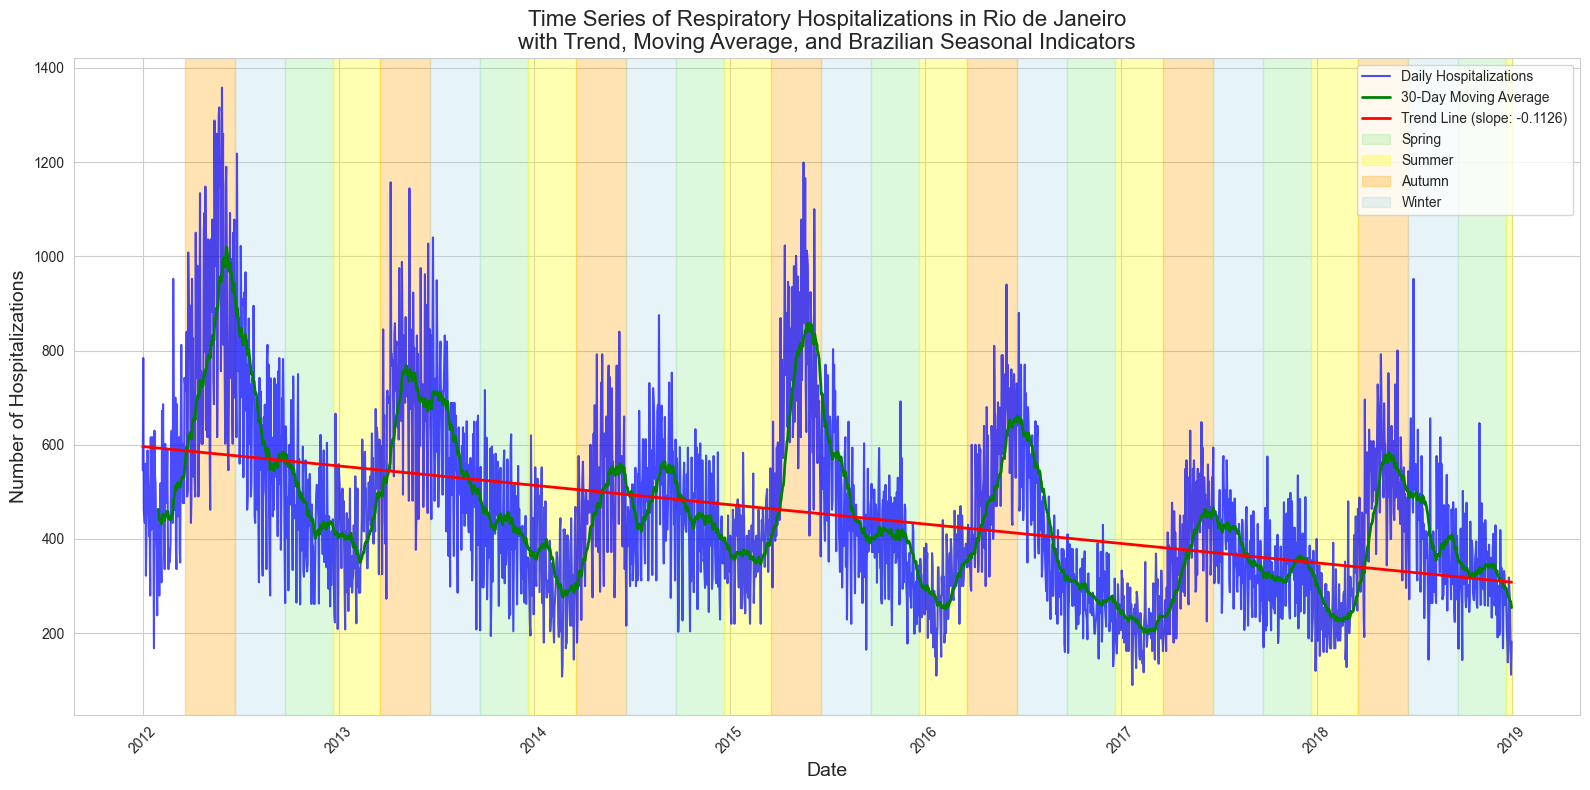

In [18]:
sns.set_style("whitegrid")
plt.figure(figsize=(16, 8))

# Série temporal de hospitalizações diárias
plt.plot(internacoes_rj['data_dia'], internacoes_rj['num_internacoes'], linewidth=1.5, color='blue', alpha=0.7, label='Daily Hospitalizations')

# Média móvel de 30 dias
internacoes_rj['moving_avg_30'] = internacoes_rj['num_internacoes'].rolling(window=30).mean()
plt.plot(internacoes_rj['data_dia'], internacoes_rj['moving_avg_30'], linewidth=2, color='green', label='30-Day Moving Average')

# Calcula a tendência linear (slope) e plota a linha de tendência
x_numeric = (internacoes_rj['data_dia'] - internacoes_rj['data_dia'].min()).dt.days
slope, intercept, r_value, p_value, std_err = linregress(x_numeric, internacoes_rj['num_internacoes'])
trend_line = slope * x_numeric + intercept
plt.plot(internacoes_rj['data_dia'], trend_line, color='red', linewidth=2, label=f'Trend Line (slope: {slope:.4f})')

# Adicionar indicadores sazonais brasileiros (estações do ano)
start_date = internacoes_rj['data_dia'].min()
end_date = internacoes_rj['data_dia'].max()

# Datas das estações do ano
def get_season_periods(year):
    return [
        ('Spring', pd.Timestamp(year=year, month=9, day=22), pd.Timestamp(year=year, month=12, day=21)),
        ('Summer', pd.Timestamp(year=year, month=12, day=21), pd.Timestamp(year=year+1, month=3, day=20)),
        ('Autumn', pd.Timestamp(year=year, month=3, day=20), pd.Timestamp(year=year, month=6, day=21)),
        ('Winter', pd.Timestamp(year=year, month=6, day=21), pd.Timestamp(year=year, month=9, day=22))
    ]

season_colors = {
    'Spring': ('lightgreen', 0.3),
    'Summer': ('yellow', 0.3),
    'Autumn': ('orange', 0.3),
    'Winter': ('lightblue', 0.3)
}

for year in range(start_date.year, end_date.year + 1):
    season_periods = get_season_periods(year)
    for season_name, season_start, season_end in season_periods:
        # Adjust for data range
        actual_start = max(season_start, start_date)
        actual_end = min(season_end, end_date)
        if actual_start < actual_end:
            color, alpha = season_colors[season_name]
            plt.axvspan(actual_start, actual_end, color=color, alpha=alpha, label=season_name if year == start_date.year else "")

plt.title('Time Series of Respiratory Hospitalizations in Rio de Janeiro\nwith Trend, Moving Average, and Brazilian Seasonal Indicators', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Number of Hospitalizations', fontsize=14)
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Serie diaria de internacoes por Unidade Hospitalar

Nesta secao, geramos a serie diaria por unidade hospitalar, agrupando por `data_dia` e `CGC_HOSP`.

### Corrigindo data e padronizando identificador do hospital

In [47]:
sus_filtrado_unidade_hospitalar = sus_filtrado.copy()

sus_filtrado_unidade_hospitalar['data_dia'] = pd.to_datetime(
    sus_filtrado_unidade_hospitalar['data_formatada'], errors='coerce'
).dt.normalize()

sus_filtrado_unidade_hospitalar['CGC_HOSP'] = (
    sus_filtrado_unidade_hospitalar['CGC_HOSP'].astype('string').str.strip()
)

### Removendo unidades hospitalares vazias ou nulas

In [48]:
sus_filtrado_unidade_hospitalar = sus_filtrado_unidade_hospitalar[
    sus_filtrado_unidade_hospitalar['data_dia'].notna()
    & sus_filtrado_unidade_hospitalar['CGC_HOSP'].notna()
    & (sus_filtrado_unidade_hospitalar['CGC_HOSP'] != '')
].copy()

### Agrupando por Unidade Hospitalar e data

In [49]:
internacoes_diario_hospital = (
    sus_filtrado_unidade_hospitalar
    .groupby(['CGC_HOSP', 'data_dia'])
    .size()
    .rename('num_internacoes')
    .astype('int64')
    .reset_index()
    .sort_values(['CGC_HOSP', 'data_dia'])
)

display(internacoes_diario_hospital)

,CGC_HOSP,data_dia,num_internacoes
0,00254512000184,2012-01-01,28
1,00254512000184,2012-01-02,98
2,00254512000184,2012-01-04,14
3,00254512000184,2012-01-05,28
4,00254512000184,2012-01-06,70
...,...,...,...
40970,60922168000429,2014-12-22,11
40971,60922168000429,2015-01-27,11
40972,60922168000429,2015-02-23,11
40973,60922168000429,2018-03-09,8


### Preenchendo calendário completo para cada unidade hospitalar

In [50]:
idx_full_hospital = pd.date_range(
    internacoes_diario_hospital['data_dia'].min(),
    internacoes_diario_hospital['data_dia'].max(),
    freq='D',
)

hospitais = (
    internacoes_diario_hospital['CGC_HOSP']
    .drop_duplicates()
    .sort_values()
)

idx_hospital_dia = pd.MultiIndex.from_product(
    [hospitais, idx_full_hospital],
    names=['CGC_HOSP', 'data_dia'],
)

internacoes_diario_hospital = (
    internacoes_diario_hospital
    .set_index(['CGC_HOSP', 'data_dia'])
    .reindex(idx_hospital_dia, fill_value=0)
    .reset_index()
)

display(internacoes_diario_hospital)

,CGC_HOSP,data_dia,num_internacoes
0,00254512000184,2012-01-01,28
1,00254512000184,2012-01-02,98
2,00254512000184,2012-01-03,0
3,00254512000184,2012-01-04,14
4,00254512000184,2012-01-05,28
...,...,...,...
306835,60922168002553,2018-12-27,0
306836,60922168002553,2018-12-28,0
306837,60922168002553,2018-12-29,0
306838,60922168002553,2018-12-30,0


### Salvando internações por unidade

In [ ]:
project_root = Path().resolve().parents[2]
output_dir = project_root / 'Data' / 'IntermediaryData' / 'DataSus'
output_dir.mkdir(parents=True, exist_ok=True)

output_csv_hospital_path = output_dir / 'respiratory_hospitalization_time_series_by_hospital.csv'
internacoes_diario_hospital.to_csv(output_csv_hospital_path, index=False, encoding='utf-8')

print(f'Arquivo salvo em: {output_csv_hospital_path}')
print(f'Dimensoes da serie por hospital: {internacoes_diario_hospital.shape}')
display(internacoes_diario_hospital.head())

### Série de internações (Escolher qual unidade analisar)

In [53]:
internacoes_diario_hospital['CGC_HOSP'].unique()

<StringArray>
['00254512000184', '00394544020100', '00394544020291', '00394544020372',
 '00394544020453', '00394544021000', '00394544021182', '00394544021263',
 '00394544021344', '00830507000172',
 ...
 '42498717001399', '42498717001470', '42498717001801', '42498717007915',
 '42498717008130', '42498717010622', '42498717012595', '53221255004995',
 '60922168000429', '60922168002553']
Length: 120, dtype: string

In [66]:
internacoes_diario_hospital_grafico = internacoes_diario_hospital[internacoes_diario_hospital['CGC_HOSP'] == '32352809000179']

internacoes_diario_hospital_grafico

,CGC_HOSP,data_dia,num_internacoes
209674,32352809000179,2012-01-01,0
209675,32352809000179,2012-01-02,0
209676,32352809000179,2012-01-03,0
209677,32352809000179,2012-01-04,0
209678,32352809000179,2012-01-05,0
...,...,...,...
212226,32352809000179,2018-12-27,0
212227,32352809000179,2018-12-28,0
212228,32352809000179,2018-12-29,0
212229,32352809000179,2018-12-30,0


C:\Users\João Henrique\AppData\Local\Temp\ipykernel_15300\901658852.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internacoes_diario_hospital_grafico['moving_avg_30'] = internacoes_diario_hospital_grafico['num_internacoes'].rolling(window=30).mean()


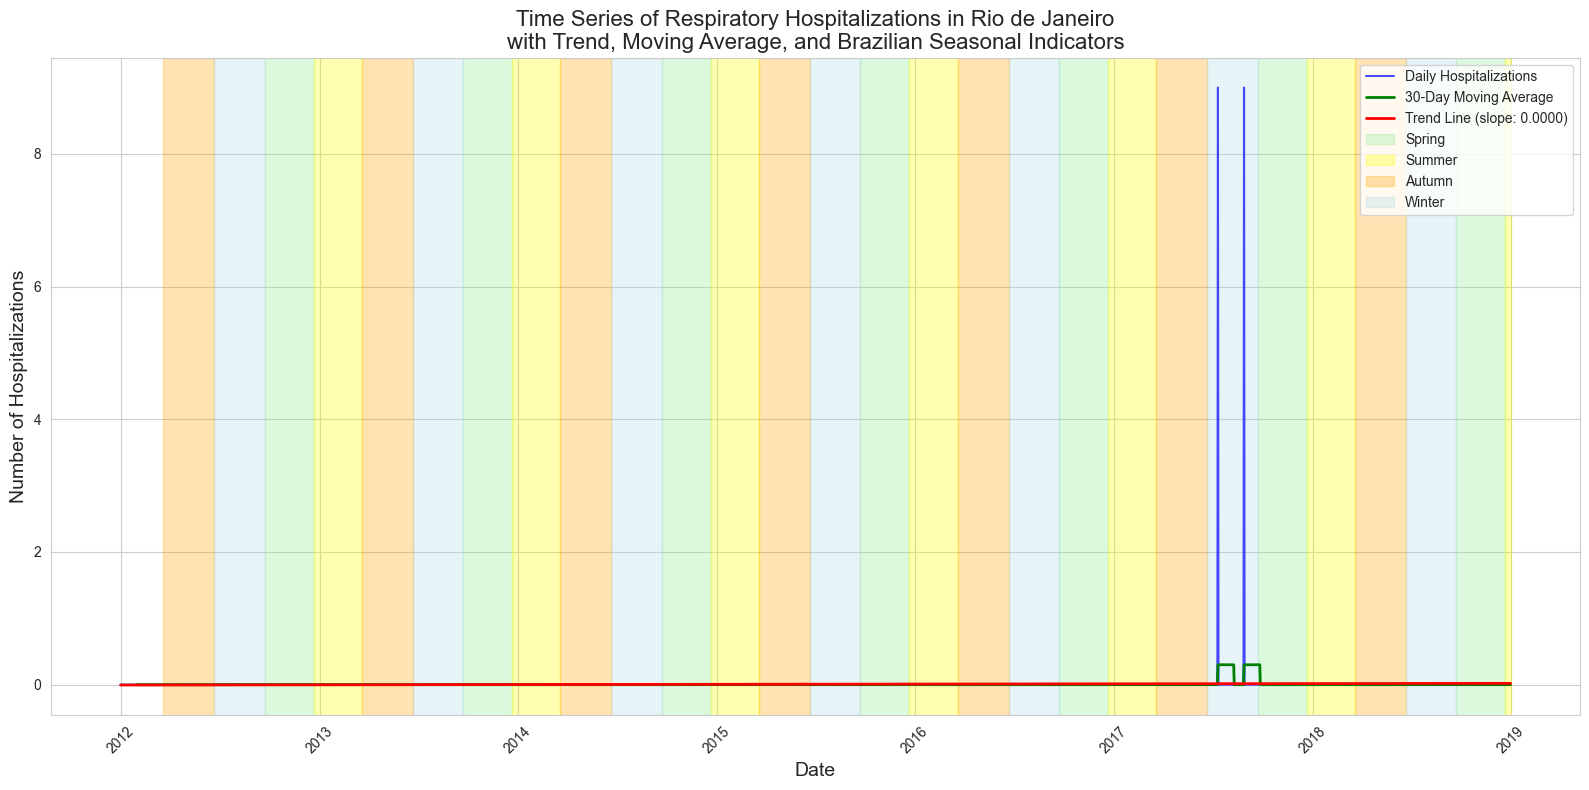

In [67]:
sns.set_style("whitegrid")
plt.figure(figsize=(16, 8))

# Série temporal de hospitalizações diárias
plt.plot(internacoes_diario_hospital_grafico['data_dia'], internacoes_diario_hospital_grafico['num_internacoes'], linewidth=1.5, color='blue', alpha=0.7, label='Daily Hospitalizations')

# Média móvel de 30 dias
internacoes_diario_hospital_grafico['moving_avg_30'] = internacoes_diario_hospital_grafico['num_internacoes'].rolling(window=30).mean()
plt.plot(internacoes_diario_hospital_grafico['data_dia'], internacoes_diario_hospital_grafico['moving_avg_30'], linewidth=2, color='green', label='30-Day Moving Average')

# Calcula a tendência linear (slope) e plota a linha de tendência
x_numeric = (internacoes_diario_hospital_grafico['data_dia'] - internacoes_diario_hospital_grafico['data_dia'].min()).dt.days
slope, intercept, r_value, p_value, std_err = linregress(x_numeric, internacoes_diario_hospital_grafico['num_internacoes'])
trend_line = slope * x_numeric + intercept
plt.plot(internacoes_diario_hospital_grafico['data_dia'], trend_line, color='red', linewidth=2, label=f'Trend Line (slope: {slope:.4f})')

# Adicionar indicadores sazonais brasileiros (estações do ano)
start_date = internacoes_diario_hospital_grafico['data_dia'].min()
end_date = internacoes_diario_hospital_grafico['data_dia'].max()

# Datas das estações do ano
def get_season_periods(year):
    return [
        ('Spring', pd.Timestamp(year=year, month=9, day=22), pd.Timestamp(year=year, month=12, day=21)),
        ('Summer', pd.Timestamp(year=year, month=12, day=21), pd.Timestamp(year=year+1, month=3, day=20)),
        ('Autumn', pd.Timestamp(year=year, month=3, day=20), pd.Timestamp(year=year, month=6, day=21)),
        ('Winter', pd.Timestamp(year=year, month=6, day=21), pd.Timestamp(year=year, month=9, day=22))
    ]

season_colors = {
    'Spring': ('lightgreen', 0.3),
    'Summer': ('yellow', 0.3),
    'Autumn': ('orange', 0.3),
    'Winter': ('lightblue', 0.3)
}

for year in range(start_date.year, end_date.year + 1):
    season_periods = get_season_periods(year)
    for season_name, season_start, season_end in season_periods:
        # Adjust for data range
        actual_start = max(season_start, start_date)
        actual_end = min(season_end, end_date)
        if actual_start < actual_end:
            color, alpha = season_colors[season_name]
            plt.axvspan(actual_start, actual_end, color=color, alpha=alpha, label=season_name if year == start_date.year else "")

plt.title('Time Series of Respiratory Hospitalizations in Rio de Janeiro\nwith Trend, Moving Average, and Brazilian Seasonal Indicators', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Number of Hospitalizations', fontsize=14)
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()